In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
import datetime as dt
from cycler import cycler
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
import matplotlib.patches as mpatches
from pdb import set_trace

from gfatpy.lidar.preprocessing import preprocess
from gfatpy.utils.plot import color_list
from gfatpy.lidar.preprocessing.gluing_proportional import gluing
from gfatpy.lidar.plot.quicklook import quicklook_xarray
from gfatpy.lidar.retrieval.klett import klett_rcs
from gfatpy.lidar.retrieval.raman import retrieve_extinction, retrieve_backscatter
from gfatpy.lidar.depolarization.retrieval import add_depolarization_products
from gfatpy.lidar.depolarization import io
from gfatpy.lidar.utils.utils import signal_to_rcs
from gfatpy.atmo import atmo, ecmwf

%load_ext autoreload
%autoreload 2

%matplotlib inline

In [99]:
data = r'W:\UGR\alhambra\1a\2023\02\22\alh_1a_Prs_rs_xf_20230222.nc'
GHK_DIR = Path(r"W:\UGR\alhambra\QA\GHK")
ETA_DIR = Path(r"W:\UGR\alhambra\QA\depolarization_calibration")
ov_file = Path(r"W:\UGR\alhambra\QA\overlap\2023\02\22\overlap_alh_ff_20230222_0100-0159.nc")

lidar = preprocess(data, apply_ov=False, overlap_path=ov_file)

z = lidar.range.values

In [65]:
lidar

<xarray.Dataset>
Dimensions:            (time: 1343, range: 5333, channel: 31)
Coordinates:
  * time               (time) datetime64[ns] 2023-06-27T00:07:58 ... 2023-06-...
  * range              (range) float32 3.75 7.5 11.25 ... 1.999e+04 2e+04 2e+04
  * channel            (channel) object '355npa' '531fta' ... '532nsp' '1064ntp'
Data variables: (12/64)
    signal_1064fta     (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    stderr_1064fta     (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    signal_1061fta     (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    stderr_1061fta     (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    signal_1061ftp     (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    stderr_1061ftp     (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    ...                 ...
    signal_408nta      (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    signal_408ntp      (time, range) float64 dask.array<chunksize=(1343, 5333), meta=np.ndarray>
    overlap_corrected  (channel) float64 0.0 1.0 1.0 0.0 1.0 ... 1.0 0.0 0.0 0.0
    overlap_355fpa     (range) float64 nan nan nan nan nan ... 1.0 1.0 1.0 1.0
    overlap_532fta     (range) float64 nan nan nan nan nan ... 1.0 1.0 1.0 1.0
    overlap_1064fta    (range) float64 nan nan nan nan nan ... 1.0 1.0 1.0 1.0
Attributes: (12/13)
    history:               Created Wed Aug  9 10:17:21 2023
    generated_with:        linc-1.7.0-py3.10
    location:              Granada
    system:                ALHAMBRA
    manufacturers:         Raymetrics
    overlap_is_corrected:  false
    ...                    ...
    BCK_MAX_ALT:           60000
    dc_corrected:          True
    dt_corrected:          True
    bg_corrected:          True
    bz_corrected:          True
    ov_corrected:          True

In [100]:
lidar = add_depolarization_products(lidar, ghk_dir=GHK_DIR, depo_calib_dir=ETA_DIR)


<class 'numpy.ndarray'>


(<Figure size 1500x500 with 2 Axes>,
 <Axes: xlabel='Time, $[UTC]$', ylabel='Height, $[m, \\, agl]$'>)

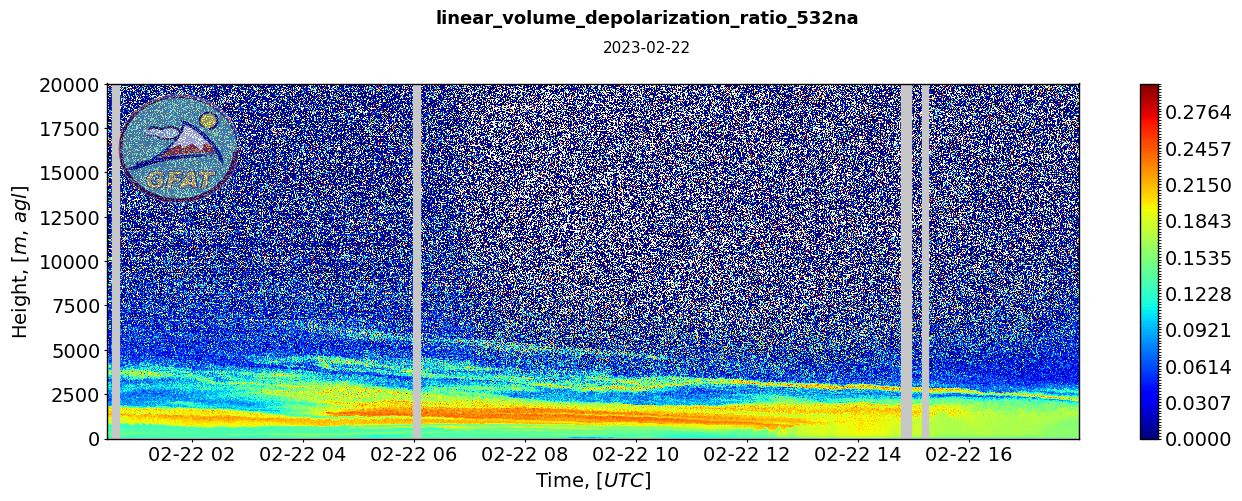

In [101]:
quicklook_xarray(lidar.linear_volume_depolarization_ratio_532na, is_rcs=True, scale_bounds=(0,0.3))

<class 'numpy.ndarray'>


(<Figure size 1500x500 with 2 Axes>,
 <Axes: xlabel='Time, $[UTC]$', ylabel='Height, $[m, \\, agl]$'>)

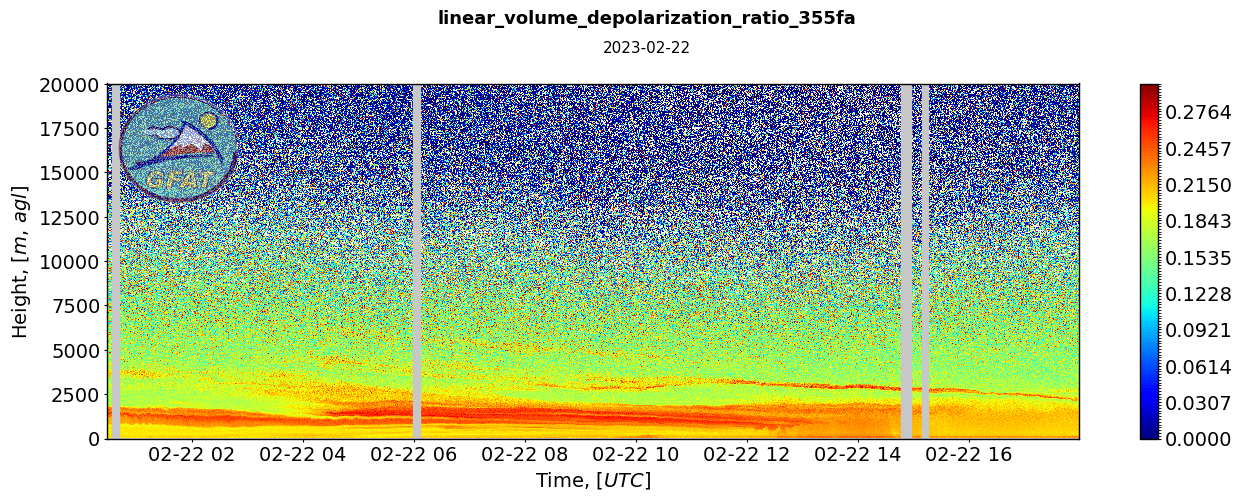

In [102]:
quicklook_xarray(lidar.linear_volume_depolarization_ratio_355fa, is_rcs=True, scale_bounds=(0,0.3))

<class 'numpy.ndarray'>


(<Figure size 1500x500 with 2 Axes>,
 <Axes: xlabel='Time, $[UTC]$', ylabel='Height, $[m, \\, agl]$'>)

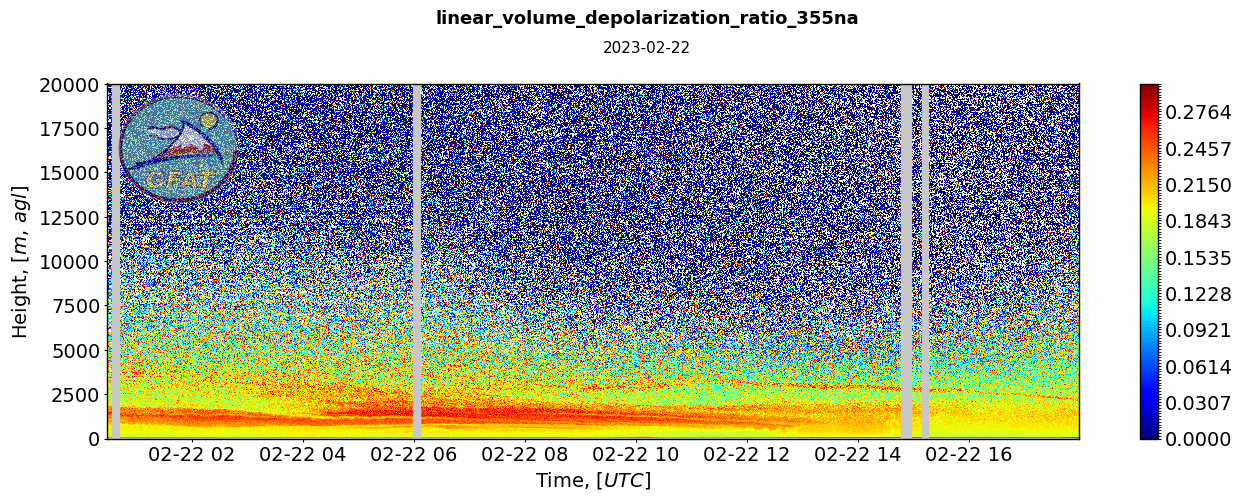

In [103]:
quicklook_xarray(lidar.linear_volume_depolarization_ratio_355na, is_rcs=True, scale_bounds=(0,0.3))

In [108]:
ecmwf_data = ecmwf.get_ecmwf_temperature_pressure(datetime(2022, 2, 22), heights=z)
P = ecmwf_data.pressure.values
T = ecmwf_data.temperature.values

atmo_data = atmo.molecular_properties(
    532,
    P,
    T,
    heights=z,
    component = 'cabannes'
)

time_tuple = ('2023-02-22T08:00:00', '2023-02-22T08:30:00')
rcs = signal_to_rcs(lidar.signal_532nta.sel(time=slice(*time_tuple)).mean('time'), lidar.range.values)

lvdr = lidar.linear_volume_depolarization_ratio_532na.sel(time=slice(*time_tuple)).mean('time')

lr_part = 53
beta = klett_rcs(rcs.values, range_profile = rcs.range.values, beta_mol_profile=atmo_data["molecular_beta"], lr_aer=lr_part, reference=(6000,7000))

R = beta/atmo_data['molecular_beta'] + 1

# molecular_depolarization = 0.00493   # 355fa
molecular_depolarization = 0.007 #532na

lpdr_532na = ((1 + molecular_depolarization) * lvdr * R - (1 + lvdr) * molecular_depolarization ) /  \
        ( (1 + molecular_depolarization) * R - (1 + lvdr)    )


In [109]:
ecmwf_data = ecmwf.get_ecmwf_temperature_pressure(datetime(2022, 2, 22), heights=z)
P = ecmwf_data.pressure.values
T = ecmwf_data.temperature.values

atmo_data = atmo.molecular_properties(
    355,
    P,
    T,
    heights=z,
    component = 'cabannes'
)

time_tuple = ('2023-02-22T08:00:00', '2023-02-22T08:30:00')
rcs = signal_to_rcs(lidar.signal_355nta.sel(time=slice(*time_tuple)).mean('time'), lidar.range.values)

lvdr = lidar.linear_volume_depolarization_ratio_355na.sel(time=slice(*time_tuple)).mean('time')

lr_part = 50
beta_355na = klett_rcs(rcs.values, range_profile = rcs.range.values, beta_mol_profile=atmo_data["molecular_beta"], lr_aer=lr_part, reference=(6000,7000))

R = beta_355na/atmo_data['molecular_beta'] + 1

molecular_depolarization = 0.00493   # 355na
# molecular_depolarization = 0.007 #532na

lpdr_355na = ((1 + molecular_depolarization) * lvdr * R - (1 + lvdr) * molecular_depolarization ) /  \
        ( (1 + molecular_depolarization) * R - (1 + lvdr)    )



In [110]:
ecmwf_data = ecmwf.get_ecmwf_temperature_pressure(datetime(2022, 2, 22), heights=z)
P = ecmwf_data.pressure.values
T = ecmwf_data.temperature.values

atmo_data = atmo.molecular_properties(
    355,
    P,
    T,
    heights=z,
    component = 'cabannes'
)

time_tuple = ('2023-02-22T08:00:00', '2023-02-22T08:30:00')
rcs = signal_to_rcs(lidar.signal_355fta.sel(time=slice(*time_tuple)).mean('time'), lidar.range.values)

lvdr = lidar.linear_volume_depolarization_ratio_355fa.sel(time=slice(*time_tuple)).mean('time')

lr_part = 50
beta_355fa = klett_rcs(rcs.values, range_profile = rcs.range.values, beta_mol_profile=atmo_data["molecular_beta"], lr_aer=lr_part, reference=(6000,7000))

R = beta_355fa/atmo_data['molecular_beta'] + 1

molecular_depolarization = 0.00493   # 355fa
# molecular_depolarization = 0.007 #532na

lpdr_355fa = ((1 + molecular_depolarization) * lvdr * R - (1 + lvdr) * molecular_depolarization ) /  \
        ( (1 + molecular_depolarization) * R - (1 + lvdr)    )



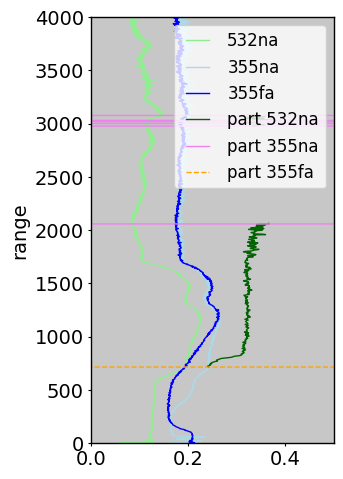

In [116]:
fig, ax = plt.subplots(figsize=(3,6))
time_tuple = ('2023-02-22T02:00:00', '2023-02-22T03:00:00')
lidar.linear_volume_depolarization_ratio_532np.sel(time=slice(*time_tuple)).mean('time').plot(y='range', c='lightgreen', label='532na')
lidar.linear_volume_depolarization_ratio_355np.sel(time=slice(*time_tuple)).mean('time').plot(y='range', c='lightblue', label='355na')
lidar.linear_volume_depolarization_ratio_355fp.sel(time=slice(*time_tuple)).mean('time').plot(y='range', c='blue', label='355fa')
lpdr_532na.where(R>1.2).plot(y='range', ax=ax, c ='darkgreen', label='part 532na')
lpdr_355na.where(R>1.2).plot(y='range', ax=ax, c ='violet', label='part 355na')
lpdr_355fa.where(R>1.2).plot(y='range', ax=ax, c ='orange', ls='--',label='part 355fa')
plt.xlim(0, 0.5)
plt.ylim(0, 4000)
plt.legend()


In [ ]:
# One figure wit three subplots (axes) in a row
fig, ax = plt.subplots(1, 4, figsize=(15, 7))

signal_355npa = lidar.signal_355npa.sel(time=slice(*time_tuple)).mean('time') 
signal_355fpa = lidar.signal_355fpa.sel(time=slice(*time_tuple)).mean('time')
signal_355nsa = lidar.signal_355nsa.sel(time=slice(*time_tuple)).mean('time') 
signal_355fsa = lidar.signal_355fsa.sel(time=slice(*time_tuple)).mean('time')
signal_532nta = lidar.signal_532nta.sel(time=slice(*time_tuple)).mean('time') 
signal_532fta = lidar.signal_532fta.sel(time=slice(*time_tuple)).mean('time')
signal_532nsa = lidar.signal_532nsa.sel(time=slice(*time_tuple)).mean('time') 
signal_532npa = lidar.signal_532npa.sel(time=slice(*time_tuple)).mean('time')


#Plot R and T signals
signal_to_rcs(signal_355npa,lidar.range.values).plot(y='range', c='lightgreen', label='355npa', ax=ax[0])
signal_to_rcs(signal_355fpa,lidar.range.values).plot(y='range', c='green', label='355fpa', ax=ax[0])
# lidar.signal_355npa.sel(time=slice(*time_tuple)).mean('time').plot(y='range', c='lightblue', label='355npa', ax=ax[0])
# lidar.signal_355fpa.sel(time=slice(*time_tuple)).mean('time').plot(y='range', c='blue', label='355fpa', ax=ax[0])

ax[0].set_xlabel("signal | rcs")
ax[0].set_ylabel("Range (m)")
ax[0].set_ylim(0,2000)
ax[0].legend()

signal_to_rcs(signal_355nsa, lidar.range.values).plot(y='range', c='lightblue', label='355nsa', ax=ax[1])
signal_to_rcs(signal_355fsa, lidar.range.values).plot(y='range', c='blue', label='355fsa', ax=ax[1])
# lidar.signal_355nsa.sel(time=slice(*time_tuple)).mean('time').plot(y='range', c='lightblue', label='355nsa', ax=ax[1])
# lidar.signal_355fsa.sel(time=slice(*time_tuple)).mean('time').plot(y='range', c='blue', label='355fsa', ax=ax[1])

ax[1].set_xlabel("signal | rcs")
ax[1].set_ylabel("Range (m)")
ax[1].set_ylim(0,2000)
ax[1].legend()

ratio_fn_355pa = signal_355fpa/ signal_355npa
ratio_fn_355sa = signal_355fsa/ signal_355nsa
ratio_fn_532ta = signal_532fta/ signal_532nta
ratio_fn_355pa.plot(y='range', c='blue', label='ratio_fn_355pa', ax=ax[2])
ratio_fn_355sa.plot(y='range', c='deepskyblue', label='ratio_fn_355sa', ax=ax[2])
ratio_fn_532ta.plot(y='range', c='green', label='ratio_fn_532ta', ax=ax[2])
ax[2].set_xlabel("Ratio")
ax[2].set_ylabel("Range (m)")
ax[2].set_ylim(0,2000)
ax[2].set_xlim(-10,10)
ax[2].legend()


ratio_sp_355fa = signal_355fsa/ signal_355fpa
ratio_sp_355na = signal_355nsa/ signal_355npa
ratio_sp_532na = signal_532nsa/ signal_532npa
ratio_sp_355fa.plot(y='range', c='blue', label='ratio_sp_355fa', ax=ax[3])
ratio_sp_355na.plot(y='range', c='deepskyblue', label='ratio_sp_355na', ax=ax[3])
ratio_sp_532na.plot(y='range', c='green', label='ratio_sp_532na', ax=ax[3])
ax[3].set_xlabel("Ratio")
ax[3].set_ylabel("Range (m)")
ax[3].set_ylim(0,2000)
ax[3].set_xlim(0,2)
ax[3].legend()


In [52]:
lpdr.sel(range=slice(1000,2000)).mean('range')

<xarray.DataArray ()>
array(0.32391829)

In [10]:
lidar.linear_volume_depolarization_ratio_532na

<xarray.DataArray 'linear_volume_depolarization_ratio_532na' (time: 1343,
                                                              range: 5333)>
array([[ 1.12877736e-01,  1.26749375e-01,  1.61261416e-01, ...,
        -1.23907175e-01, -2.79580859e+00,  1.27525502e-01],
       [ 1.14490315e-01,  1.26563199e-01,  1.62557290e-01, ...,
        -4.27768354e+00,  9.89182944e-01, -2.13675390e-01],
       [ 1.11743869e-01,  1.17354197e-01,  1.63512638e-01, ...,
        -3.08118578e-01, -4.01258387e-01, -5.27696133e-01],
       ...,
       [ 1.42262640e-01,  1.90378975e-01,  1.93239020e-01, ...,
        -2.09199006e-02,  5.37484770e-02,  4.16791032e-03],
       [ 1.45845911e-01,  1.76709825e-01,  1.93188314e-01, ...,
        -1.04553203e+01, -1.17146250e-01, -1.12920014e-01],
       [ 1.45943190e-01,  2.00009189e-01,  1.97811223e-01, ...,
        -6.65403856e-02, -8.20568877e-01,  4.85160261e-02]])
Coordinates:
  * time     (time) datetime64[ns] 2023-06-27T00:07:58 ... 2023-06-27T23:58:46
  * range    (range) float32 3.75 7.5 11.25 15.0 ... 1.999e+04 2e+04 2e+04
Attributes:
    long_name:             Linear Volume Depolarization Ratio
    detection_mode:        0
    wavelength:            532
    units:                 $\#$
    calibration_datetime:  20230626_2209

In [11]:
wavelength_, telescope_, mode_ = 355, 'f', 'a'
calibration = xr.open_dataset(ETA_DIR / "alh_eta-star_20230626_2209.nc")
eta_star = calibration[ f"eta_star_mean_{wavelength_}{telescope_}{mode_}" ].item()
eta_star

0.1432705061513972

In [27]:
ghk_file = Path(r"W:\UGR\alhambra\QA\GHK\output_optic_input_alh_hwp_355f_20230623_GHK_0.9.8h_Py3.7.dat")
ghk = io.ghk_output_reader(ghk_file)
ghk
K = ghk["K2"]
GT = ghk["GT"]
HT = ghk["HT"]
GR = ghk["GR"]
HR = ghk["HR"]

eta_original = eta_star / K

eta_calculos = (0.035* eta_star) / 1.002 

eta_original, eta_calculos

time_tuple = ('2023-06-27T00:07:00', '2023-06-27T00:48:00')
channel_R, channel_T = '355fpa', '355fsa'

signal_R = lidar[f"signal_{channel_R}"].sel(time=slice(*time_tuple),range=slice(0,8000)).mean('time')
rcs_R = signal_to_rcs(signal_R, signal_R.range)

signal_T = lidar[f"signal_{channel_T}"].sel(time=slice(*time_tuple),range=slice(0,8000)).mean('time')
rcs_T = signal_to_rcs(signal_T, signal_T.range)

total_signal = eta_star * HR * signal_T - HT*signal_R                            
rcs_total = signal_to_rcs(total_signal, total_signal.range)

ratio = (signal_R / signal_T) 

# Remove zeros from ratio to avoid division by zero
lvdr = (((GT + HT) * ratio - (GR + HR)) / ((GR - HR) - (GT - HT) * ratio)).astype(
    float
)
z = lvdr.range.values

ecmwf_data = ecmwf.get_ecmwf_temperature_pressure(datetime(2022, 9, 3), heights=z)
P = ecmwf_data.pressure.values
T = ecmwf_data.temperature.values

atmo_data = atmo.molecular_properties(
    355,
    P,
    T,
    heights=z,
)

lr_part = 50
beta = klett_rcs(rcs_total.values, range_profile = rcs_total.range.values, beta_mol_profile=atmo_data["molecular_beta"], lr_aer=lr_part, reference=(6000,7000))

R = beta/atmo_data['molecular_beta'] + 1

molecular_depolarization = 0.00493  

lpdr = ((1 + molecular_depolarization) * lvdr * R - (1 + lvdr) * molecular_depolarization ) /  \
        ( (1 + molecular_depolarization) * R - (1 + lvdr)    )


NameError: name 'eta_star' is not defined

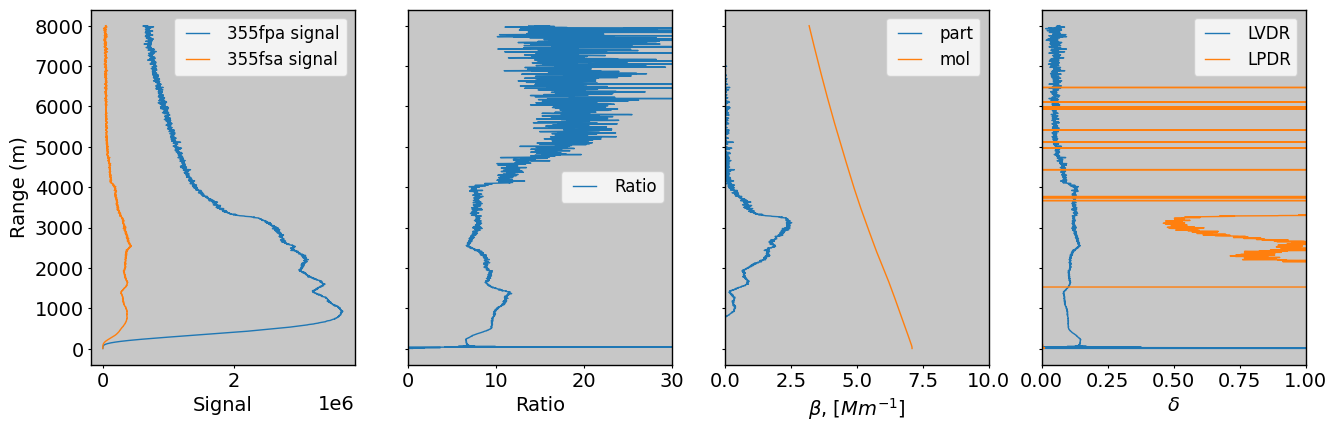

In [61]:
# One figure wit three subplots (axes) in a row
fig, ax = plt.subplots(1, 4, figsize=(15, 5))

#Plot R and T signals
ax[0].plot(rcs_R, rcs_R.range, label=f"{channel_R} signal")
ax[0].plot(rcs_T, rcs_T.range, label=f"{channel_T} signal")
ax[0].set_xlabel("Signal")
ax[0].set_ylabel("Range (m)")
ax[0].legend()

# Plot ratio
ax[1].plot(ratio, ratio.range, label="Ratio")
ax[1].set_xlabel("Ratio")
ax[1].set_ylabel("")
ax[1].set_yticklabels([])
ax[1].set_xlim(0,30)
ax[1].legend()

# Plot backscatter
ax[2].plot(beta*1e6, z, label="part")
ax[2].plot(atmo_data['molecular_beta']*1e6, z, label="mol")
ax[2].set_xlabel(r"$\beta$, [$Mm^{-1}$]")
ax[2].set_ylabel("")
ax[2].set_yticklabels([])
ax[2].set_xlim(0,10)
ax[2].legend()

# Plot LDR
ax[3].plot(lvdr, lvdr.range, label="LVDR")
ax[3].plot(lpdr, lpdr.range, label="LPDR")
ax[3].set_xlabel("$\delta$")
ax[3].set_ylabel("")
ax[3].set_yticklabels([])
ax[3].set_xlim(0,1)
ax[3].legend()



(0.0, 0.1)

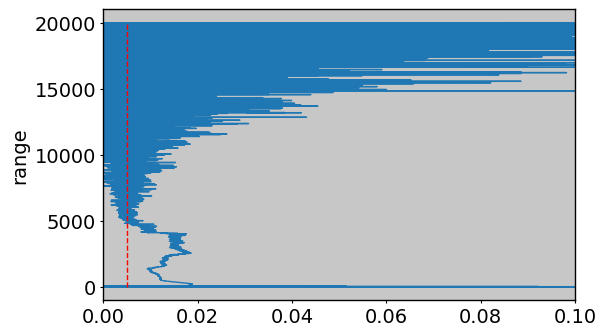

In [12]:
lvdr_.plot(y='range')
plt.vlines(0.005,0,20000,linestyles='dashed',color='red')
plt.xlim(0,0.1)